In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("../data/processed/historical_data.csv", parse_dates=["timestamp"])
df = df.sort_values(["city", "timestamp"]).reset_index(drop=True)

In [8]:
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"]       = df["timestamp"].dt.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

grp = df.groupby("city")
df["pm2_5_lag_1h"]   = grp["pm2_5_ugm3"].shift(1)
df["pm2_5_lag_24h"]  = grp["pm2_5_ugm3"].shift(24)
df["pm2_5_lag_168h"] = grp["pm2_5_ugm3"].shift(168)
df["no2_lag_1h"]     = grp["nitrogen_dioxide_ugm3"].shift(1)

def roll(col, window, func="mean", min_periods=1):
    return df.groupby("city")[col].transform(
        lambda x: getattr(x.rolling(window, min_periods=min_periods), func)()
    )

df["pm2_5_roll_mean_3h"]  = roll("pm2_5_ugm3", 3)
df["pm2_5_roll_mean_24h"] = roll("pm2_5_ugm3", 24)
df["pm2_5_roll_mean_7d"]  = roll("pm2_5_ugm3", 168)
df["pm2_5_roll_std_24h"]  = roll("pm2_5_ugm3", 24, func="std", min_periods=2)

df["city_encoded"] = (df["city"] == "surabaya").astype(int)

df_model = df.dropna().reset_index(drop=True)

feature_cols = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m_c", "relative_humidity_pct", "wind_speed_10m_kmh",
    "pm2_5_lag_1h", "pm2_5_lag_24h", "pm2_5_lag_168h", "no2_lag_1h",
    "pm2_5_roll_mean_3h", "pm2_5_roll_mean_24h", "pm2_5_roll_mean_7d", "pm2_5_roll_std_24h",
    "city_encoded",
]
target_col = "pm2_5_ugm3"

print(f"df_model shape: {df_model.shape}")
print(f"Features: {len(feature_cols)}, Target: {target_col}")


df_model shape: (7968, 25)
Features: 16, Target: pm2_5_ugm3


In [9]:
split_date = "2026-06-01"

train = df_model[df_model["timestamp"] < split_date]
test  = df_model[df_model["timestamp"] >= split_date]

X_train, y_train = train[feature_cols], train[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {train['timestamp'].min().date()} -> {train['timestamp'].max().date()} ({len(train)} rows)")
print(f"Test : {test['timestamp'].min().date()}  -> {test['timestamp'].max().date()} ({len(test)} rows)")

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{name}")
    print(f"  MAE  : {mae:.2f} µg/m³")
    print(f"  RMSE : {rmse:.2f} µg/m³")
    print(f"  MAPE : {mape:.2f}%")
    return {"mae": mae, "rmse": rmse, "mape": mape}

naive_pred = X_test["pm2_5_lag_24h"]
results = {}
results["naive"] = evaluate("Naive Baseline (lag 24h)", y_test, naive_pred)


Train: 2026-01-08 -> 2026-05-31 (6912 rows)
Test : 2026-06-01  -> 2026-06-22 (1056 rows)

Naive Baseline (lag 24h)
  MAE  : 13.12 µg/m³
  RMSE : 18.61 µg/m³
  MAPE : 28.92%


In [10]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
results["xgboost"] = evaluate("XGBoost", y_test, xgb_pred)

# Perbandingan
print("\n=== Perbandingan ===")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 52)
for name, r in results.items():
    print(f"{name:<25} {r['mae']:>7.2f}  {r['rmse']:>7.2f}  {r['mape']:>7.2f}%")



XGBoost
  MAE  : 4.17 µg/m³
  RMSE : 6.47 µg/m³
  MAPE : 7.87%

=== Perbandingan ===
Model                          MAE     RMSE     MAPE
----------------------------------------------------
naive                       13.12    18.61    28.92%
xgboost                      4.17     6.47     7.87%


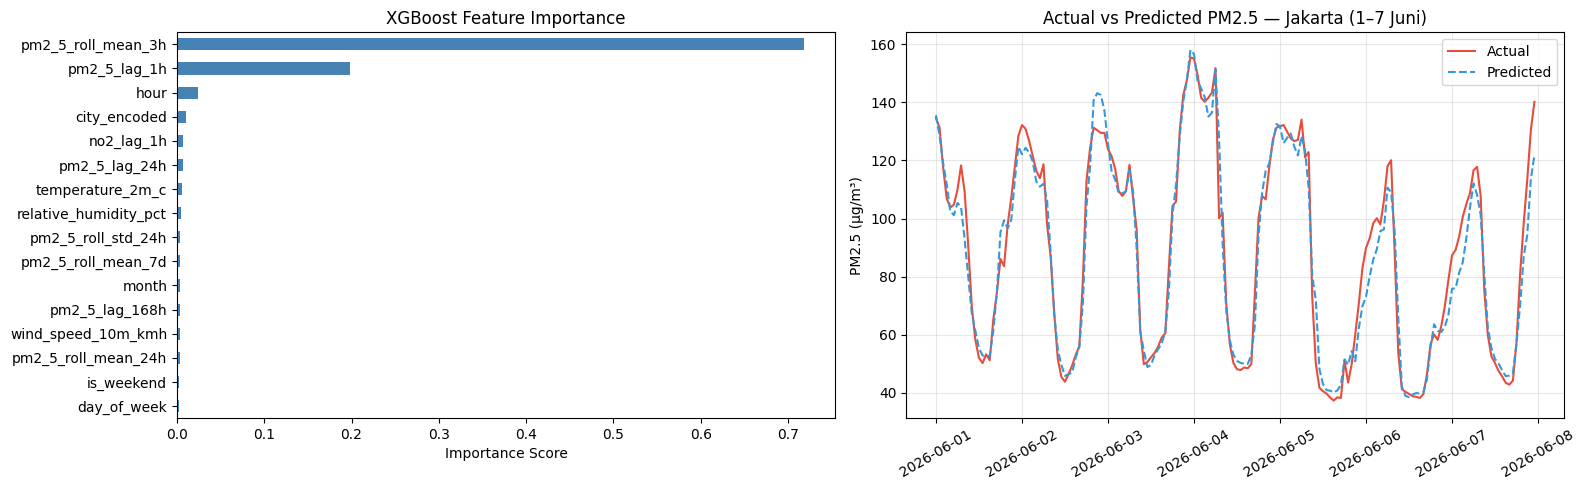

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values()
feat_imp.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost Feature Importance")
axes[0].set_xlabel("Importance Score")

mask = (test["city"] == "jakarta") & (test["timestamp"] < "2026-06-08")
idx  = test[mask].index

axes[1].plot(test.loc[idx, "timestamp"], y_test.loc[idx],
             label="Actual", color="#e74c3c", linewidth=1.5)
axes[1].plot(test.loc[idx, "timestamp"], xgb_pred[test.index.get_indexer(idx)],
             label="Predicted", color="#3498db", linewidth=1.5, linestyle="--")
axes[1].set_title("Actual vs Predicted PM2.5 — Jakarta (1–7 Juni)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
